In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


*BAGGING

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

from xgboost import XGBClassifier
import seaborn as sns
sns.set()

In [3]:
# Load Dataset

df = pd.read_csv('Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
#Check the dataset shape.
print(df.shape)

(255347, 18)


In [5]:
#Check Data Type.
print(df.dtypes)

LoanID                str
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object


In [6]:
#Identify missing values in each column.
print(df.isnull().sum())

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [7]:
print(df.columns.to_list())

['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [8]:
# Delete Column
df.drop('LoanID',axis=1,inplace=True)

In [9]:
binary_col = ['HasMortgage','HasDependents','HasCoSigner']
for col in binary_col:
    df[col] = df[col].map({'Yes':1,'No':0})

In [10]:
categorical_col = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']
for col in categorical_col:
    df[col] = df[col].astype('category').cat.codes

df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


In [11]:
print(df.isnull().sum())

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [12]:
X = df.drop('Default', axis=1)
y = df['Default']

In [13]:
# Traning data 75% AND # Testing data 25%

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [14]:
# Using Random Forest Model
rf = RandomForestClassifier(n_estimators=200,random_state=42)

# Train Model
rf.fit(X_train, y_train)

# Prediction
y_pred = rf.predict(X_test)

print("Accuracy ",accuracy_score(y_test,y_pred))
print("Classification Report ",classification_report(y_test,y_pred))

Accuracy  0.8859908830302176
Classification Report                precision    recall  f1-score   support

           0       0.89      1.00      0.94     56410
           1       0.64      0.05      0.09      7427

    accuracy                           0.89     63837
   macro avg       0.76      0.52      0.51     63837
weighted avg       0.86      0.89      0.84     63837



*BOOSTING

In [19]:
# XGboost Model

xgb = XGBClassifier(n_estimators=300, 
    learning_rate = (0.05), 
    max_depth = 4, 
    sub_samples = 0.8, 
    random_state = 42,
    eval_metric = "logloss"
                   )



xgb.fit(X_train,y_train)
xgb_pred = xgb.predict(X_test)

print("Accuracy : - ",accuracy_score(y_test,xgb_pred))
print("Classification Report : - ",classification_report(y_test,xgb_pred))

C:\Users\Priyank\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:35:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "sub_samples" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy : -  0.886836787443019
Classification Report : -                precision    recall  f1-score   support

           0       0.89      0.99      0.94     56410
           1       0.63      0.07      0.12      7427

    accuracy                           0.89     63837
   macro avg       0.76      0.53      0.53     63837
weighted avg       0.86      0.89      0.84     63837



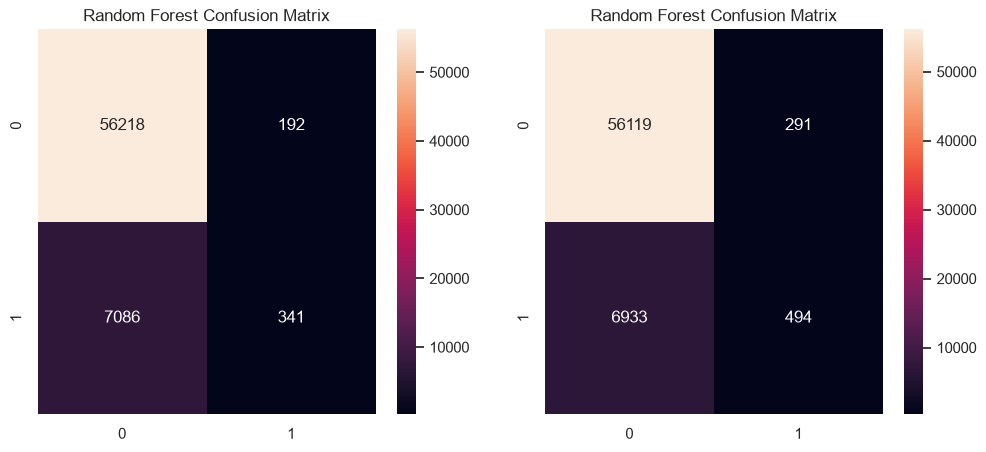

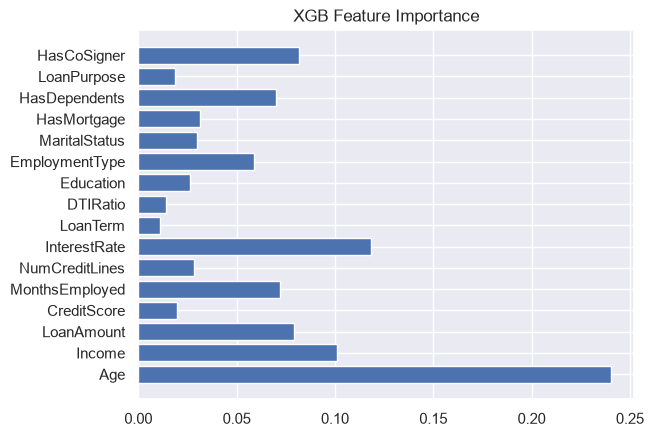

In [24]:
# Confusion Matrix

fig , ax = plt.subplots(1,2,figsize=(12,5))

sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d",ax=ax[0])
ax[0].set_title("Random Forest Confusion Matrix")

sns.heatmap(confusion_matrix(y_test,xgb_pred),annot=True,fmt="d",ax=ax[1])
ax[1].set_title("Random Forest Confusion Matrix")

plt.show()

importance = xgb.feature_importances_
plt.barh(X.columns,importance)
plt.title("XGB Feature Importance")
plt.show()